# Phase 2 — Signal Preprocessing & Feature Engineering

AI-Kennzeichnung: AI wurde verwendet, um physische Logiken des Projekts zu verstehen, bewusste architektonische Entscheidungen zu unterstützen, Code-Qualität/Struktur sowie Kommentare zu verbessern. 

## 1. Import and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as sig
from pathlib import Path

from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import balanced_accuracy_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 10)

In [2]:
DATA_PATH     = Path("condition+monitoring+of+hydraulic+systems")
FEATURES_PATH = Path("features_phase2.csv")
IQR_FACTOR    = 1.5
STABLE_FILTER   = False
CORR_THRESHOLD  = 0.95

PROFILE_COLS = ["Cooler", "Valve", "Pump_leakage", "Accumulator", "Stable"]
TARGET_COL   = "Accumulator"

SENSORS_100HZ = ["PS1", "PS2", "PS3", "PS4", "PS5", "PS6", "EPS1"]
SENSORS_10HZ  = ["FS1", "FS2"]
SENSORS_1HZ   = ["TS1", "TS2", "TS3", "TS4", "VS1", "CE", "CP", "SE"]
SENSORS_ALL   = SENSORS_100HZ + SENSORS_10HZ + SENSORS_1HZ

SAMPLING_RATES = (
    {s: 100 for s in SENSORS_100HZ}
    | {s: 10  for s in SENSORS_10HZ}
    | {s: 1   for s in SENSORS_1HZ}
)

LOWPASS_CUTOFF_HZ = 10.0
LOWPASS_ORDER     = 5
DOWNSAMPLE_FACTOR = 10

CLASSES       = [90, 100, 115, 130]
CLASS_COLORS  = {90: "#E24B4A", 100: "#EF9F27", 115: "#1D9E75", 130: "#185FA5"}
CLASS_LABELS  = {90: "90 bar (kurz vor Versagen)", 100: "100 bar (starke Reduktion)",
                 115: "115 bar (leichte Reduktion)", 130: "130 bar (optimal)"}

In [3]:
def load_sensor(name: str) -> np.ndarray:
    """Load sensor time series. Returns array of shape (2205, timesteps)."""
    return np.loadtxt(DATA_PATH / f"{name}.txt")


def load_profile() -> pd.DataFrame:
    """Load condition profile with all 5 target variable columns."""
    return pd.read_csv(DATA_PATH / "profile.txt", sep="\t", header=None, names=PROFILE_COLS)

In [4]:
profile = load_profile()
y = profile[TARGET_COL].values

raw_sensors = {name: load_sensor(name) for name in SENSORS_ALL}

print(f"Zyklen: {len(y)}, Sensoren: {len(raw_sensors)}")
print(f"\nKlassenverteilung Accumulator:")
print(pd.Series(y).value_counts().sort_index().to_string())

Zyklen: 2205, Sensoren: 17

Klassenverteilung Accumulator:
90     808
100    399
115    399
130    599


### 1.1 Stabilitätsflag

Der Datensatz enthält ein `Stable`-Flag, das anzeigt, ob ein Messzyklus unter stabilen Betriebsbedingungen aufgezeichnet wurde.

**Entscheidung:** Instabile Zyklen werden beibehalten (`STABLE_FILTER = False`).
**Begründung:** Das Stable-Flag beschreibt den Betriebszustand, nicht die Messqualität. Der Akkumulator-Zustand ist unabhängig davon. Ein Zustandsüberwachungssystem muss Fehler auch unter instabilen Bedingungen erkennen.

In [5]:
stable_counts = profile["Stable"].value_counts().sort_index()
print("Stabile Zyklen   (Stable=1):", stable_counts.get(1, 0),
      f"({stable_counts.get(1, 0) / len(profile) * 100:.1f} %)")
print("Instabile Zyklen (Stable=0):", stable_counts.get(0, 0),
      f"({stable_counts.get(0, 0) / len(profile) * 100:.1f} %)")

if STABLE_FILTER:
    stable_mask = profile["Stable"].values == 1
    y           = y[stable_mask]
    raw_sensors = {name: data[stable_mask] for name, data in raw_sensors.items()}
    print(f"\nNach Filterung: {len(y)} Zyklen")
else:
    print("\nInstabile Zyklen beibehalten.")

Stabile Zyklen   (Stable=1): 756 (34.3 %)
Instabile Zyklen (Stable=0): 1449 (65.7 %)

Instabile Zyklen beibehalten.


## 2. Signalanalyse
Vor der Vorverarbeitung analysieren wir die Signale im Zeit-, Frequenz- und Zeit-Frequenzbereich, um die Preprocessing-Entscheidungen datenbasiert zu begründen.

### 2.1 Mittlerer Signalverlauf pro Klasse

In [6]:
def plot_mean_signal_per_class(
    sensor_data: np.ndarray,
    labels: np.ndarray,
    sampling_rate: int,
    sensor_name: str,
) -> None:
    """Plot mean signal ± std per accumulator class for one sensor."""
    t = np.arange(sensor_data.shape[1]) / sampling_rate

    fig, ax = plt.subplots(figsize=(12, 4))
    for cls in CLASSES:
        mask = labels == cls
        mean = sensor_data[mask].mean(axis=0)
        std  = sensor_data[mask].std(axis=0)
        ax.plot(t, mean, label=CLASS_LABELS[cls], color=CLASS_COLORS[cls])
        ax.fill_between(t, mean - std, mean + std, alpha=0.15, color=CLASS_COLORS[cls])

    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel("Wert")
    ax.set_title(f"Mittlerer Signalverlauf ± Standardabweichung pro Klasse — {sensor_name} ({sampling_rate} Hz)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

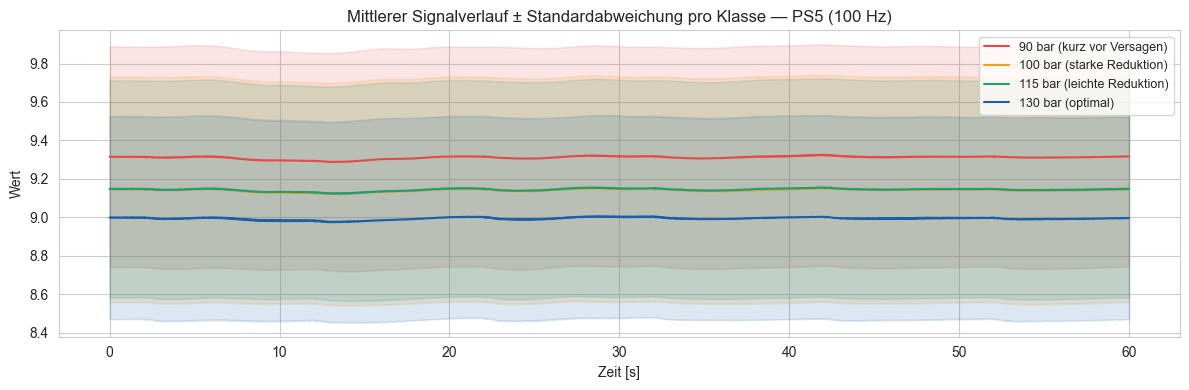

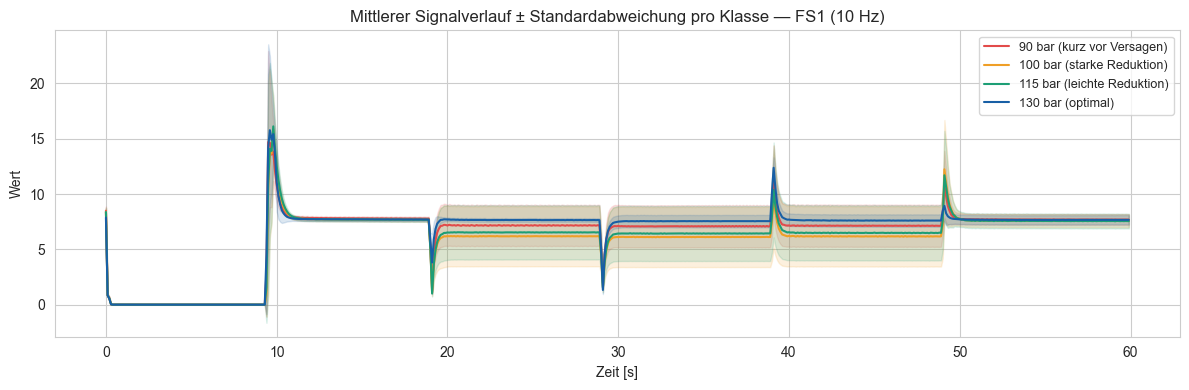

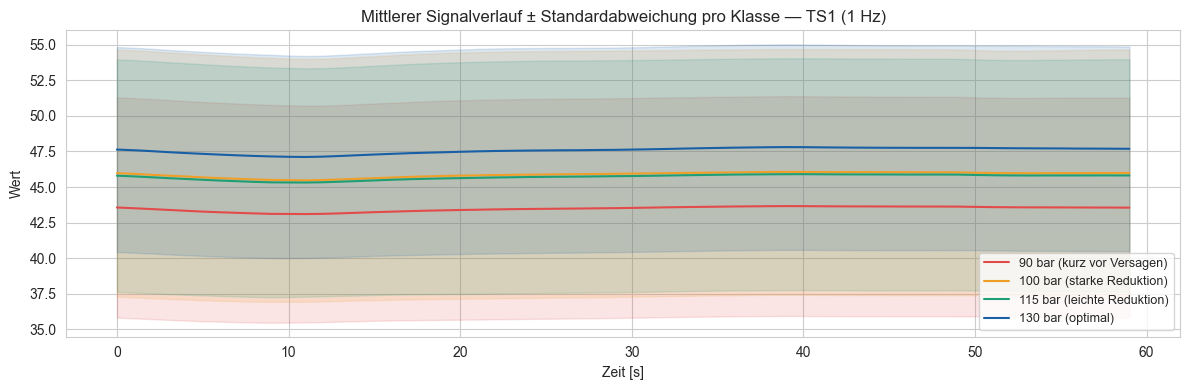

In [7]:
for sensor in ["PS5", "FS1", "TS1"]:
    plot_mean_signal_per_class(raw_sensors[sensor], y, SAMPLING_RATES[sensor], sensor)

### 2.2 Frequenzbereich — FFT

In [8]:
def compute_mean_spectrum_per_class(
    sensor_data: np.ndarray,
    labels: np.ndarray,
    sampling_rate: int,
) -> dict[int, tuple[np.ndarray, np.ndarray]]:
    """Compute mean FFT magnitude spectrum per class. Returns {class: (freqs, spectrum)}."""
    result = {}
    for cls in CLASSES:
        mask    = labels == cls
        spectra = np.abs(np.fft.rfft(sensor_data[mask], axis=1))
        freqs   = np.fft.rfftfreq(sensor_data.shape[1], d=1.0 / sampling_rate)
        result[cls] = (freqs, spectra.mean(axis=0))
    return result


def plot_mean_spectrum_per_class(
    sensor_data: np.ndarray,
    labels: np.ndarray,
    sampling_rate: int,
    sensor_name: str,
    max_freq: float | None = None,
) -> None:
    """Plot mean FFT magnitude spectrum per class for one sensor."""
    spectra  = compute_mean_spectrum_per_class(sensor_data, labels, sampling_rate)
    freq_cap = max_freq or (sampling_rate / 2)

    fig, ax = plt.subplots(figsize=(10, 4))
    for cls, (freqs, spectrum) in spectra.items():
        mask = freqs <= freq_cap
        ax.plot(freqs[mask], spectrum[mask], label=CLASS_LABELS[cls], color=CLASS_COLORS[cls])

    ax.set_xlabel("Frequenz [Hz]")
    ax.set_ylabel("Magnitude")
    ax.set_title(f"Mittleres FFT-Spektrum pro Klasse — {sensor_name} ({sampling_rate} Hz)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

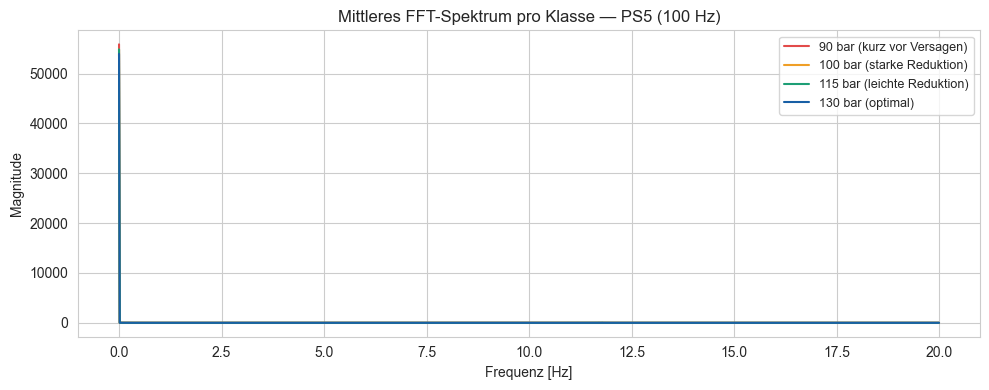

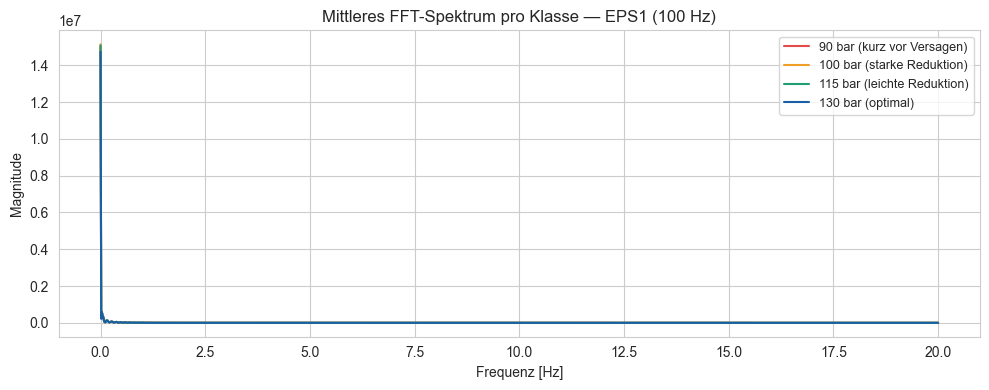

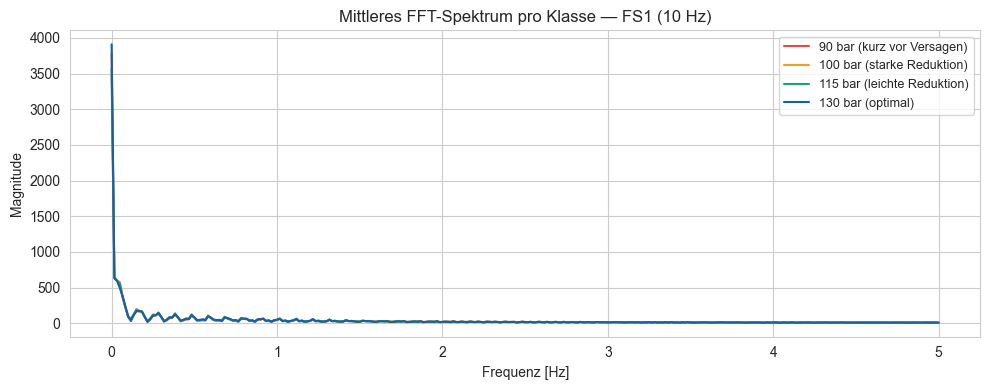

In [9]:
plot_mean_spectrum_per_class(raw_sensors["PS5"],  y, SAMPLING_RATES["PS5"],  "PS5",  max_freq=20.0)
plot_mean_spectrum_per_class(raw_sensors["EPS1"], y, SAMPLING_RATES["EPS1"], "EPS1", max_freq=20.0)
plot_mean_spectrum_per_class(raw_sensors["FS1"],  y, SAMPLING_RATES["FS1"],  "FS1")

### 2.3 Zeit-Frequenzbereich — Spektrogramm

Für ausgewählte Hochfrequenz-Sensoren zeigen wir, *wann* welche Frequenzen auftreten.

In [10]:
def plot_spectrogram_per_class(
    sensor_data: np.ndarray,
    labels: np.ndarray,
    sampling_rate: int,
    sensor_name: str,
    example_class: int = 130,
) -> None:
    """Plot spectrogram for one example cycle of the given class."""
    idx = np.where(labels == example_class)[0][0]
    signal_cycle = sensor_data[idx]

    f, t, Sxx = sig.spectrogram(signal_cycle, fs=sampling_rate, nperseg=256)

    fig, ax = plt.subplots(figsize=(10, 4))
    pcm = ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading="gouraud", cmap="viridis")
    fig.colorbar(pcm, ax=ax, label="Leistung [dB]")
    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel("Frequenz [Hz]")
    ax.set_title(f"Spektrogramm — {sensor_name}, Klasse {example_class} bar")
    ax.set_ylim(0, min(20, sampling_rate / 2))
    plt.tight_layout()
    plt.show()

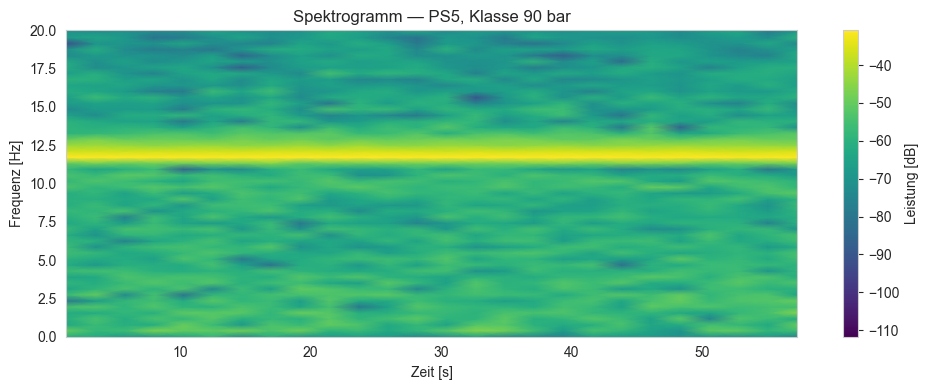

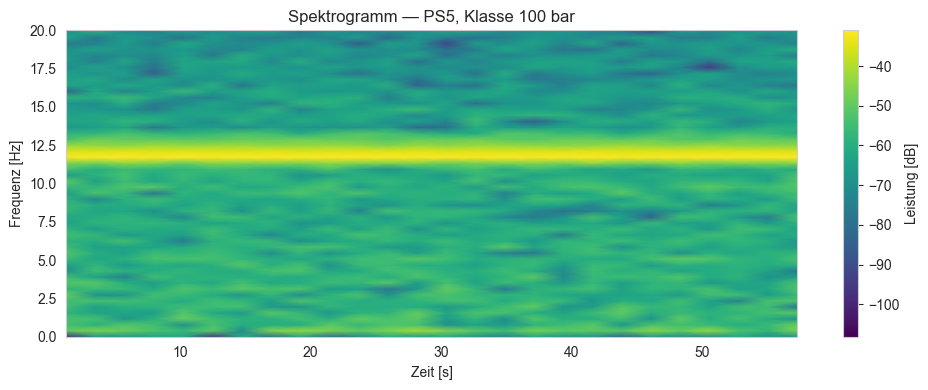

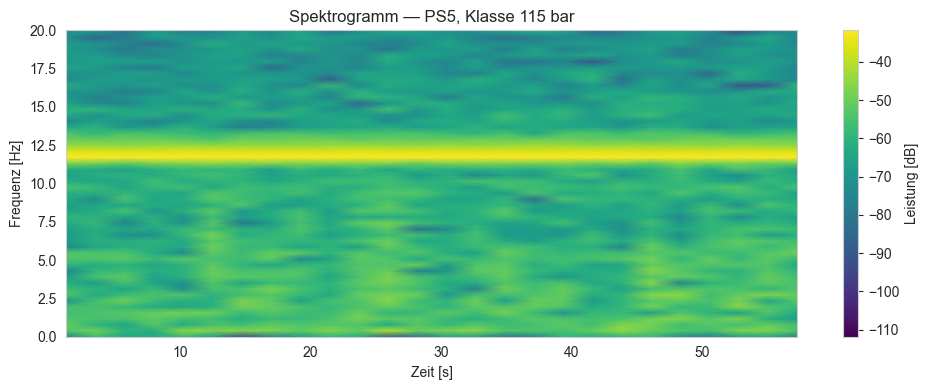

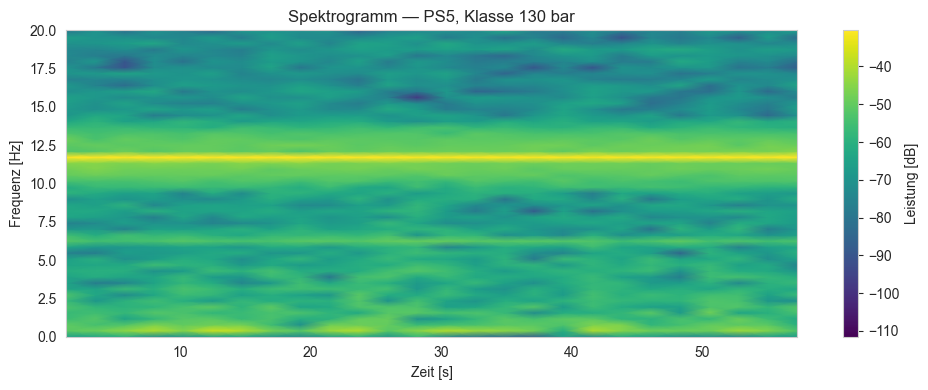

In [11]:
for cls in CLASSES:
    plot_spectrogram_per_class(raw_sensors["PS5"], y, SAMPLING_RATES["PS5"], "PS5", example_class=cls)

## 3. Signal Preprocessing

**Begründung der Entscheidungen:**

- **Ausreißerbehandlung:** IQR-basierte Erkennung (Tukey-Fence, Faktor 1.5) für alle Sensoren. IQR wurde gegenüber z-Score gewählt, da Quartile robust gegenüber Extremwerten sind — z-Score würde die Ausreißer, die er erkennen soll, selbst in Mittelwert und Standardabweichung einrechnen. Behandlung via Clipping statt Entfernung, um die Zykluslänge für tsfresh zu erhalten. Clipping wird vor der Filterung angewendet, da der Filter Ausreißer sonst über benachbarte Zeitschritte verteilen würde.
- Die FFT-Analyse zeigt, dass das Nutzsignal der Drucksensoren (PS1–PS6, EPS1) unterhalb von 10 Hz liegt. Energie oberhalb dieser Grenze ist hochfrequentes Rauschen ohne diagnostischen Mehrwert.
- Maßnahme: **Tiefpassfilter** (Butterworth, Cutoff 10 Hz) vor dem Downsampling, um Aliasing zu vermeiden. Als Implementierung wird `filtfilt` (Nullphasenfilter) statt `lfilter` verwendet, da `lfilter` eine Phasenverschiebung einführt, die zeitliche Merkmale wie Peak-Positionen verfälscht. Die Filterordnung 5 liefert einen ausreichend steilen Übergang im Stoppband, ohne numerische Instabilität zu riskieren — für industrielle Drucksensordaten ein etablierter Kompromiss.
- Maßnahme: **Downsampling** von 100 Hz auf 10 Hz (Faktor 10). Die neue Abtastrate entspricht der nativen Abtastrate der Durchflusssensoren (FS1, FS2), womit alle hochfrequenten Sensoren nach dem Preprocessing auf derselben Zeitbasis liegen. Dies vereinfacht die nachfolgende Feature-Extraktion und reduziert den Rechenaufwand erheblich.
- Sensoren mit 1 Hz und 10 Hz werden ohne Filterung übernommen, da bei diesen Abtastraten kein relevantes hochfrequentes Rauschen vorliegt.

### 3.1 Ausreißeranalyse

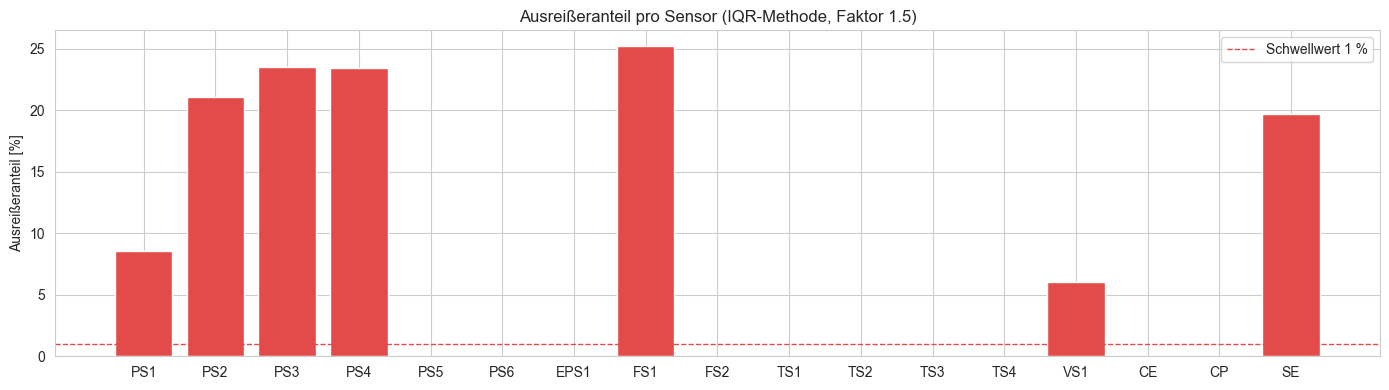

Sensor   Ausreißer [n]   Ausreißer [%]
PS1            1131463   8.5523 %
PS2            2792885   21.1102 %
PS3            3112007   23.5224 %
PS4            3101012   23.4392 %
PS5                  0   0.0000 %
PS6                  0   0.0000 %
EPS1                 0   0.0000 %
FS1             333939   25.2410 %
FS2                  0   0.0000 %
TS1                  0   0.0000 %
TS2                  0   0.0000 %
TS3                  0   0.0000 %
TS4                  0   0.0000 %
VS1               8046   6.0816 %
CE                   0   0.0000 %
CP                   0   0.0000 %
SE               26078   19.7113 %


In [12]:
def detect_outliers(
    data: np.ndarray,
    iqr_factor: float = IQR_FACTOR,
) -> dict[str, float]:
    """Detect outliers via IQR method. Returns bounds and outlier statistics."""
    q1, q3 = np.percentile(data, [25, 75])
    iqr    = q3 - q1
    return {
        "lower":      q1 - iqr_factor * iqr,
        "upper":      q3 + iqr_factor * iqr,
        "n_outliers": int(np.sum((data < q1 - iqr_factor * iqr) | (data > q3 + iqr_factor * iqr))),
        "pct":        float(np.mean((data < q1 - iqr_factor * iqr) | (data > q3 + iqr_factor * iqr)) * 100),
    }


def clip_outliers(
    data: np.ndarray,
    iqr_factor: float = IQR_FACTOR,
) -> np.ndarray:
    """Clip values outside IQR-based bounds row-wise. Returns clipped array."""
    q1, q3 = np.percentile(data, [25, 75])
    iqr    = q3 - q1
    return np.clip(data, q1 - iqr_factor * iqr, q3 + iqr_factor * iqr)


outlier_stats = {name: detect_outliers(raw_sensors[name]) for name in SENSORS_ALL}

pcts   = [outlier_stats[s]["pct"] for s in SENSORS_ALL]
colors = ["#E24B4A" if p > 1.0 else "#1D9E75" for p in pcts]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(SENSORS_ALL, pcts, color=colors, edgecolor="white")
ax.axhline(1.0, color="#E24B4A", linestyle="--", lw=1, label="Schwellwert 1 %")
ax.set_ylabel("Ausreißeranteil [%]")
ax.set_title(f"Ausreißeranteil pro Sensor (IQR-Methode, Faktor {IQR_FACTOR})")
ax.legend()
plt.tight_layout()
plt.show()

print("Sensor   Ausreißer [n]   Ausreißer [%]")
for name in SENSORS_ALL:
    s = outlier_stats[name]
    print(f"{name:6s}   {s['n_outliers']:13d}   {s['pct']:.4f} %")

In [13]:
def design_lowpass_filter(
    cutoff_hz: float,
    sampling_rate: int,
    order: int = LOWPASS_ORDER,
) -> tuple[np.ndarray, np.ndarray]:
    """Design Butterworth low-pass filter. Returns (b, a) coefficients."""
    nyquist   = sampling_rate / 2
    b, a = sig.butter(order, cutoff_hz / nyquist, btype="low", analog=False)
    return b, a


def apply_lowpass_filter(
    data: np.ndarray,
    cutoff_hz: float,
    sampling_rate: int,
) -> np.ndarray:
    """Apply zero-phase Butterworth low-pass filter row-wise (one row = one cycle)."""
    b, a = design_lowpass_filter(cutoff_hz, sampling_rate)
    return np.apply_along_axis(lambda row: sig.filtfilt(b, a, row), axis=1, arr=data)


def downsample(data: np.ndarray, factor: int) -> np.ndarray:
    """Reduce sample count by retaining every factor-th sample."""
    return data[:, ::factor]

### 3.2 Filterung & Downsampling

In [14]:
preprocessed_sensors: dict[str, np.ndarray] = {}

for name in SENSORS_ALL:
    clipped = clip_outliers(raw_sensors[name])
    if name in SENSORS_100HZ:
        filtered = apply_lowpass_filter(clipped, LOWPASS_CUTOFF_HZ, sampling_rate=100)
        preprocessed_sensors[name] = downsample(filtered, DOWNSAMPLE_FACTOR)
    else:
        preprocessed_sensors[name] = clipped

print("Shape nach Preprocessing:")
for name, arr in preprocessed_sensors.items():
    print(f"  {name:5s}: {arr.shape}  ({SAMPLING_RATES[name]} Hz → "
          f"{SAMPLING_RATES[name] // (DOWNSAMPLE_FACTOR if name in SENSORS_100HZ else 1)} Hz)")

Shape nach Preprocessing:
  PS1  : (2205, 600)  (100 Hz → 10 Hz)
  PS2  : (2205, 600)  (100 Hz → 10 Hz)
  PS3  : (2205, 600)  (100 Hz → 10 Hz)
  PS4  : (2205, 600)  (100 Hz → 10 Hz)
  PS5  : (2205, 600)  (100 Hz → 10 Hz)
  PS6  : (2205, 600)  (100 Hz → 10 Hz)
  EPS1 : (2205, 600)  (100 Hz → 10 Hz)
  FS1  : (2205, 600)  (10 Hz → 10 Hz)
  FS2  : (2205, 600)  (10 Hz → 10 Hz)
  TS1  : (2205, 60)  (1 Hz → 1 Hz)
  TS2  : (2205, 60)  (1 Hz → 1 Hz)
  TS3  : (2205, 60)  (1 Hz → 1 Hz)
  TS4  : (2205, 60)  (1 Hz → 1 Hz)
  VS1  : (2205, 60)  (1 Hz → 1 Hz)
  CE   : (2205, 60)  (1 Hz → 1 Hz)
  CP   : (2205, 60)  (1 Hz → 1 Hz)
  SE   : (2205, 60)  (1 Hz → 1 Hz)


### 3.3 Visualisierung: Vorher / Nachher

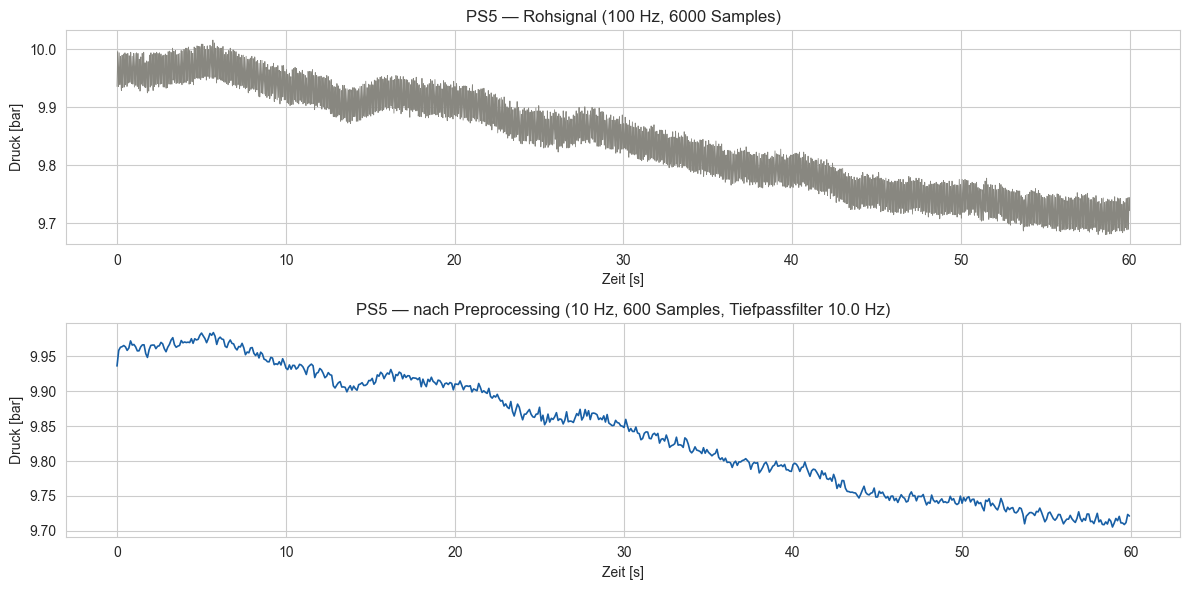

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

example_idx = np.where(y == 130)[0][0]
t_raw  = np.arange(raw_sensors["PS5"].shape[1]) / 100
t_proc = np.arange(preprocessed_sensors["PS5"].shape[1]) / (100 / DOWNSAMPLE_FACTOR)

axes[0].plot(t_raw,  raw_sensors["PS5"][example_idx],          lw=0.6, color="#888780")
axes[0].set_title("PS5 — Rohsignal (100 Hz, 6000 Samples)")
axes[0].set_xlabel("Zeit [s]")
axes[0].set_ylabel("Druck [bar]")

axes[1].plot(t_proc, preprocessed_sensors["PS5"][example_idx], lw=1.2, color=CLASS_COLORS[130])
axes[1].set_title(f"PS5 — nach Preprocessing (10 Hz, 600 Samples, Tiefpassfilter {LOWPASS_CUTOFF_HZ} Hz)")
axes[1].set_xlabel("Zeit [s]")
axes[1].set_ylabel("Druck [bar]")

plt.tight_layout()
plt.show()

### 3.4 Mittlerer Verlauf nach Preprocessing

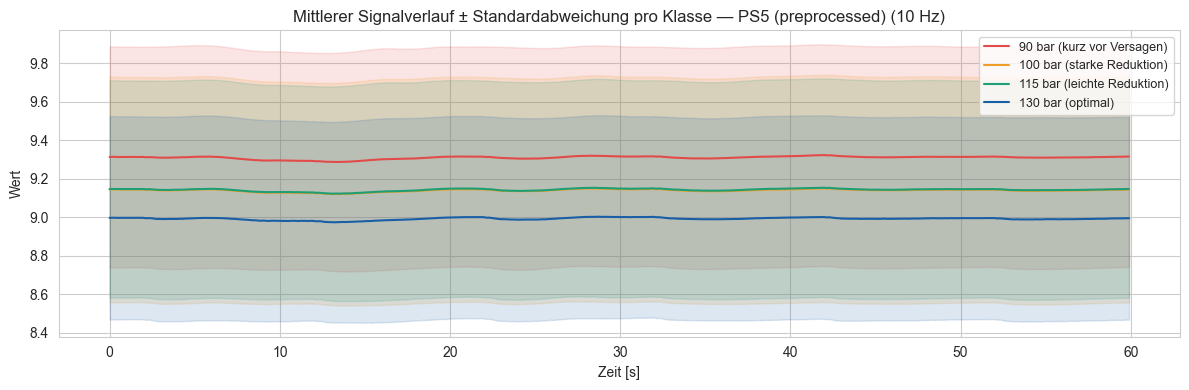

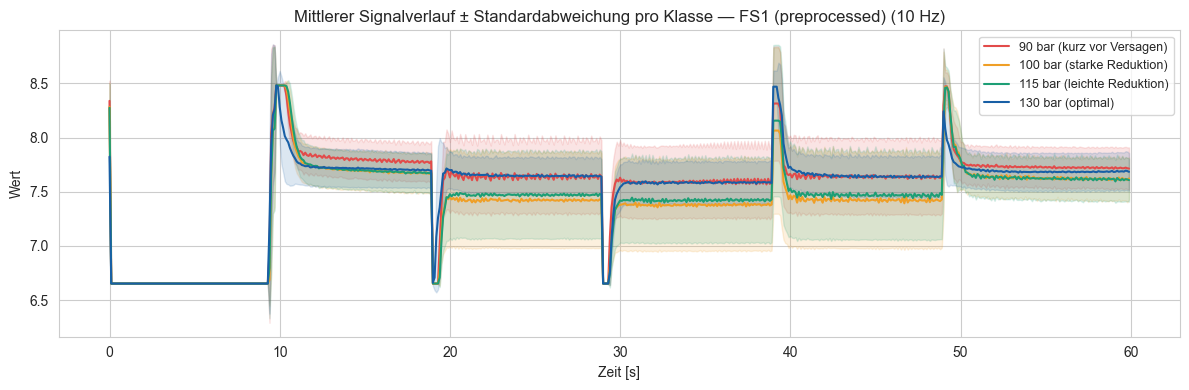

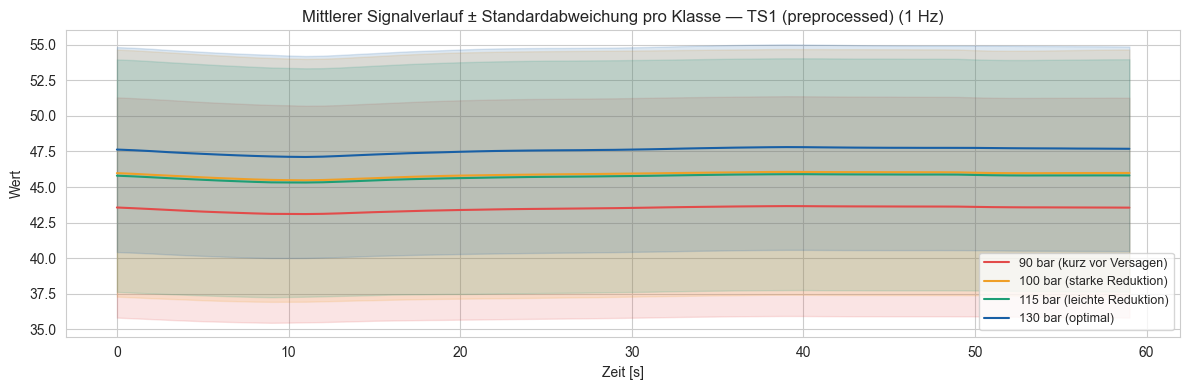

In [16]:
for sensor in ["PS5", "FS1", "TS1"]:
    sr_after = SAMPLING_RATES[sensor] // (DOWNSAMPLE_FACTOR if sensor in SENSORS_100HZ else 1)
    plot_mean_signal_per_class(preprocessed_sensors[sensor], y, sr_after, f"{sensor} (preprocessed)")

## 4. Feature Engineering

**Bibliothekswahl: tsfresh**

tsfresh extrahiert automatisch eine große Menge von Merkmalen aus Zeit-, Frequenz- und Zeit-Frequenzbereich. Verglichen mit TSFEL bietet tsfresh mehr Merkmale und eine eingebaute Relevanzfilterung. Da der Rechenaufwand durch das Downsampling auf 10 Hz erheblich reduziert wurde, ist tsfresh hier praktikabel.

Wir verwenden `EfficientFCParameters`, da diese gegenüber `ComprehensiveFCParameters` nur 6 rechenintensive Merkmale weglassen, aber die Rechenzeit deutlich reduzieren.

In [17]:
def convert_to_long_format(sensor_dict: dict[str, np.ndarray]) -> pd.DataFrame:
    """Convert preprocessed sensor arrays to tsfresh long format.

    Returns DataFrame with columns: id (str), time (int), sensor (str), value (float).
    """
    frames = []
    for name, data in sensor_dict.items():
        n_cycles, n_steps = data.shape
        frames.append(pd.DataFrame({
            "id":     np.repeat(np.arange(n_cycles), n_steps).astype(str),
            "time":   np.tile(np.arange(n_steps), n_cycles),
            "sensor": name,
            "value":  data.flatten(),
        }))
    return pd.concat(frames, ignore_index=True)

In [18]:
df_long = convert_to_long_format(preprocessed_sensors)
print(f"Long-Format Shape: {df_long.shape}")
df_long.head(3)

Long-Format Shape: (12965400, 4)


,id,time,sensor,value
0,0,0,PS1,151.476495
1,0,1,PS1,154.693401
2,0,2,PS1,160.556432


In [19]:
features_raw = extract_features(
    df_long,
    column_id="id",
    column_sort="time",
    column_kind="sensor",
    column_value="value",
    default_fc_parameters=EfficientFCParameters(),
)
print(f"Extrahierte Features (roh): {features_raw.shape}")

Feature Extraction: 100%|██████████| 30/30 [13:57<00:00, 27.92s/it]  


Extrahierte Features (roh): (2205, 13209)


### 4.1 NaN-Behandlung und Varianz-Filter

In [20]:
impute(features_raw)

selector = VarianceThreshold(threshold=0.0)
selector.fit(features_raw)
features_clean = features_raw.loc[:, selector.get_support()]

print(f"Features vor VarianceThreshold: {features_raw.shape[1]}")
print(f"Features nach VarianceThreshold: {features_clean.shape[1]}")
print(f"Entfernte Features (Varianz = 0): {features_raw.shape[1] - features_clean.shape[1]}")

C:\Users\agits\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns <StringArray>
[            'SE__fft_coefficient__attr_"real"__coeff_31',
             'SE__fft_coefficient__attr_"real"__coeff_32',
             'SE__fft_coefficient__attr_"real"__coeff_33',
             'SE__fft_coefficient__attr_"real"__coeff_34',
             'SE__fft_coefficient__attr_"real"__coeff_35',
             'SE__fft_coefficient__attr_"real"__coeff_36',
             'SE__fft_coefficient__attr_"real"__coeff_37',
             'SE__fft_coefficient__attr_"real"__coeff_38',
             'SE__fft_coefficient__attr_"real"__coeff_39',
             'SE__fft_coefficient__attr_"real"__coeff_40',
 ...
        'FS1__friedrich_coefficients__coeff_3__m_3__r_30',
               'FS1__max_langevin_fixed_point__m_3__r_30',
 'FS1__query_similarity_count__query_None__threshold_0.0',
 

Features vor VarianceThreshold: 13209
Features nach VarianceThreshold: 10037
Entfernte Features (Varianz = 0): 3172


## 5. Merkmalsanalyse

Wir analysieren, welche Features die vier Klassen am besten trennen und wie hoch die Redundanz zwischen Features ist.

### 5.1 Mittlere Feature-Werte pro Klasse (Heatmap)

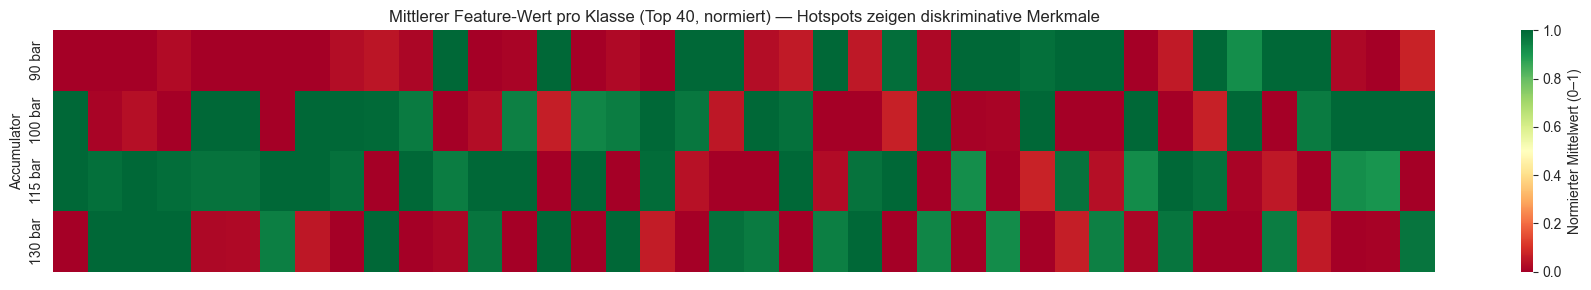

In [21]:
features_with_target = features_clean.copy()
features_with_target["Accumulator"] = y

mean_per_class = features_with_target.groupby("Accumulator")[features_clean.columns].mean()

scaler = MinMaxScaler()
mean_norm = (
    pd.DataFrame(
        scaler.fit_transform(mean_per_class),
        index=mean_per_class.index,
        columns=mean_per_class.columns,
    )
)

top_features = mean_norm.var(axis=0).nlargest(40).index

fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(
    mean_norm[top_features],
    ax=ax,
    cmap="RdYlGn",
    yticklabels=[f"{c} bar" for c in mean_norm.index],
    xticklabels=False,
    cbar_kws={"label": "Normierter Mittelwert (0–1)"},
)
ax.set_title("Mittlerer Feature-Wert pro Klasse (Top 40, normiert) — Hotspots zeigen diskriminative Merkmale")
plt.tight_layout()
plt.show()

### 5.2 Korrelationsanalyse

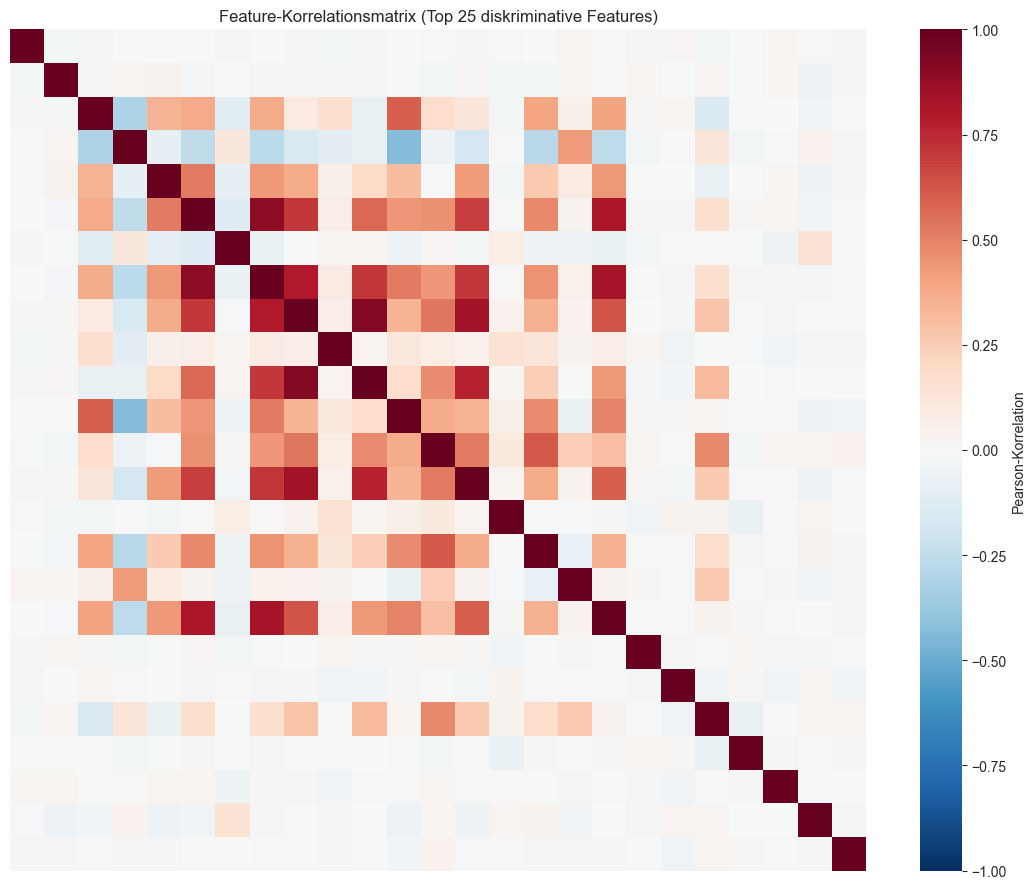

Stark korrelierte Feature-Paare (|r| > 0.9): 1


In [22]:
TOP_N_CORR = 25
top_by_variance = mean_norm.var(axis=0).nlargest(TOP_N_CORR).index
corr = features_clean[top_by_variance].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Pearson-Korrelation"},
)
ax.set_title(f"Feature-Korrelationsmatrix (Top {TOP_N_CORR} diskriminative Features)")
plt.tight_layout()
plt.show()

high_corr = (corr.abs() > 0.9) & (corr.abs() < 1.0)
print(f"Stark korrelierte Feature-Paare (|r| > 0.9): {high_corr.sum().sum() // 2}")

### 5.3 Feature-Selektion: Korrelationsfilter

Von jedem Feature-Paar mit |r| > 0.95 wird eines entfernt. Bei |r| > 0.95 erklärt ein Feature über 90 % der Varianz des anderen — der Informationsbeitrag ist vernachlässigbar. Schwellenwert 0.95 ist ein etablierter Kompromiss zwischen Dimensionsreduktion und Informationserhalt.

In [23]:
def remove_correlated_features(
    features: pd.DataFrame,
    threshold: float = CORR_THRESHOLD,
) -> pd.DataFrame:
    """Remove one feature from each pair with absolute correlation above threshold."""
    corr_matrix = features.corr().abs()
    upper       = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return features.drop(columns=to_drop)


features_selected = remove_correlated_features(features_clean)

print(f"Features vor Korrelationsfilter:               {features_clean.shape[1]}")
print(f"Features nach Korrelationsfilter (|r|>{CORR_THRESHOLD}):  {features_selected.shape[1]}")
print(f"Entfernte redundante Features:                 {features_clean.shape[1] - features_selected.shape[1]}")

Features vor Korrelationsfilter:               10037
Features nach Korrelationsfilter (|r|>0.95):  6405
Entfernte redundante Features:                 3632


In [24]:
features_selected.index = features_selected.index.astype(int)
features_selected        = features_selected.sort_index()
 
export_df                = features_selected.copy()
export_df["Accumulator"] = y
export_df["Stable"]      = profile["Stable"].values

export_df.to_csv(FEATURES_PATH)
print(f"Features gespeichert: {FEATURES_PATH}")
print(f"Shape: {export_df.shape} (inkl. Zielvariable und Stable-Flag)")
export_df.head(2)

Features gespeichert: features_phase2.csv
Shape: (2205, 6407) (inkl. Zielvariable und Stable-Flag)


,SE__sum_values,SE__mean_abs_change,SE__mean_change,SE__mean_second_derivative_central,SE__standard_deviation,...,PS6__fourier_entropy__bins_10,PS6__permutation_entropy__dimension_4__tau_1,PS6__permutation_entropy__dimension_7__tau_1,Accumulator,Stable
0,3897.555,2.362508,0.003814,0.212315,9.362843,...,0.045395,3.051428,6.224655,130,1
1,3908.261,2.336678,0.005610,0.213927,9.486360,...,0.170467,3.100334,6.242445,130,1


### 5.4 Top diskriminative Features pro Sensor

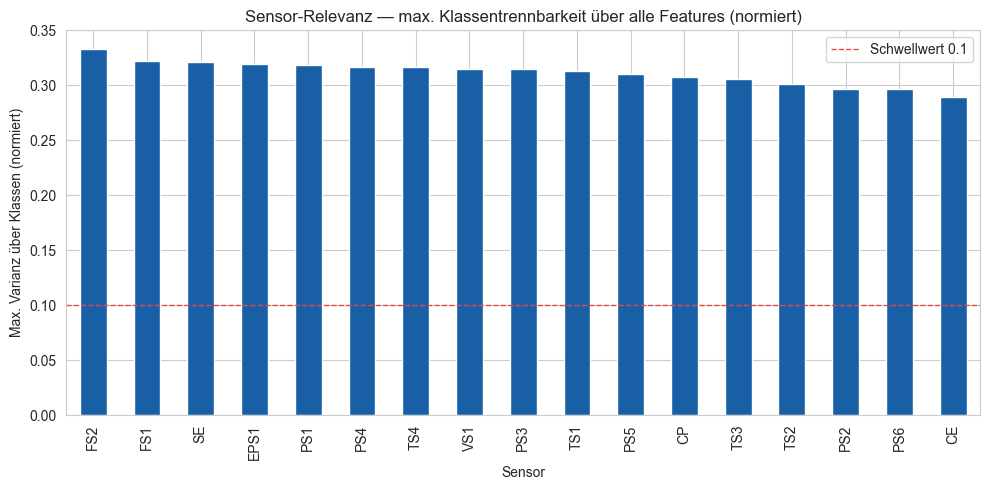

In [25]:
sensor_prefixes = {s: [] for s in SENSORS_ALL}

for col in features_clean.columns:
    for sensor in SENSORS_ALL:
        if col.startswith(sensor + "__"):
            sensor_prefixes[sensor].append(col)
            break

discriminability = mean_norm.var(axis=0)

sensor_scores = {
    sensor: discriminability[cols].max() if cols else 0.0
    for sensor, cols in sensor_prefixes.items()
}

sensor_ranking = pd.Series(sensor_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sensor_ranking.plot(kind="bar", ax=ax, color="#185FA5", edgecolor="white")
ax.set_title("Sensor-Relevanz — max. Klassentrennbarkeit über alle Features (normiert)")
ax.set_xlabel("Sensor")
ax.set_ylabel("Max. Varianz über Klassen (normiert)")
ax.axhline(0.1, color="#E24B4A", linestyle="--", lw=1, label="Schwellwert 0.1")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluationsmetriken

**Begründung:**

Die Klassenverteilung ist unbalanciert — dies macht Accuracy als primäre Metrik ungeeignet, da ein Modell, das immer die häufigste Klasse vorhersagt, bereits eine hohe Accuracy erzielen würde, ohne die seltenen Klassen zu erkennen.

Gewählte Metriken:
- **F1-Macro**: Mittelt den F1-Score gleichgewichtet über alle 4 Klassen,   unabhängig von der Klassenhäufigkeit. Primärmetrik für Phase 3.
- **Konfusionsmatrix**: Zeigt, welche Klassen miteinander verwechselt werden.   Wichtig für die Interpretation der Modellfehler.
- **Balanced Accuracy**: Mittelt Recall pro Klasse gleichgewichtig. Robuster als Accuracy bei Klassenimbalance. Sekundärmetrik für Phase 3.

Klassenverteilung:
  90 bar:   808 Zyklen (36.6 %)
  100 bar:   399 Zyklen (18.1 %)
  115 bar:   399 Zyklen (18.1 %)
  130 bar:   599 Zyklen (27.2 %)


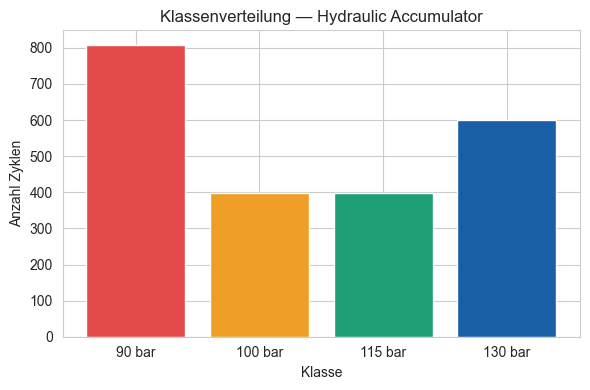


Primärmetrik Phase 3: F1-Macro
Begründung: Gleichgewichtete Bewertung aller 4 Klassen unabhängig von der Klassenhäufigkeit.

Definierte Metriken für Phase 3:
  Primär:   F1-Macro          → f1_score(..., average='macro')
  Sekundär: Balanced Accuracy → balanced_accuracy_score(...)
  Analyse:  Konfusionsmatrix  → confusion_matrix(...)


In [26]:
class_counts = pd.Series(y).value_counts().sort_index()
class_pct    = (class_counts / len(y) * 100).round(1)

print("Klassenverteilung:")
for cls in CLASSES:
    print(f"  {cls} bar: {class_counts[cls]:5d} Zyklen ({class_pct[cls]:.1f} %)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    [f"{c} bar" for c in CLASSES],
    [class_counts[c] for c in CLASSES],
    color=[CLASS_COLORS[c] for c in CLASSES],
    edgecolor="white",
)
ax.set_title("Klassenverteilung — Hydraulic Accumulator")
ax.set_xlabel("Klasse")
ax.set_ylabel("Anzahl Zyklen")
plt.tight_layout()
plt.show()

print("\nPrimärmetrik Phase 3: F1-Macro")
print("Begründung: Gleichgewichtete Bewertung aller 4 Klassen unabhängig von der Klassenhäufigkeit.")

print("\nDefinierte Metriken für Phase 3:")
print("  Primär:   F1-Macro          → f1_score(..., average='macro')")
print("  Sekundär: Balanced Accuracy → balanced_accuracy_score(...)")
print("  Analyse:  Konfusionsmatrix  → confusion_matrix(...)")